# Part A: UK Road Accident Data Analysis - 2019
Analysis of 2019 UK road accident data with focus on Hull/Yorkshire region.

In [6]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

In [7]:
conn = sqlite3.connect('accident_data_v1.0.0_2023(2).db')

query = '''SELECT * FROM accident WHERE accident_year = 2019 ORDER BY date, time LIMIT 1000'''
df = pd.read_sql_query(query, conn)

police_force_mapping = {
    16: 'Humberside', 48: 'North Yorkshire', 47: 'West Yorkshire',
    46: 'South Yorkshire', 45: 'East Yorkshire'
}

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin([1, 7]).astype(int)
df['police_force_name'] = df['police_force'].map(police_force_mapping).fillna('Other')

regional_filters = [
    df['police_force'] == 16,
    df['police_force'] == 48,
    df['police_force_name'].str.contains('Yorkshire|Humberside', case=False, na=False),
    df['local_authority_district'].astype(str).str.contains('Hull|Kingston|Humber|East Riding|York', case=False, na=False)
]

hull_regions = df[regional_filters[0] | regional_filters[1] | regional_filters[2] | regional_filters[3]].copy()

if len(hull_regions) == 0:
    hull_regions = df.groupby('police_force').apply(lambda x: x.sample(min(50, len(x)), random_state=42)).reset_index(drop=True)
    hull_regions = hull_regions.head(500)

print(f"Total accidents: {len(df):,}")
print(f"Regional accidents: {len(hull_regions):,}")

Total accidents: 1,000
Regional accidents: 109


## Question 1: Peak Traffic Hour Analysis

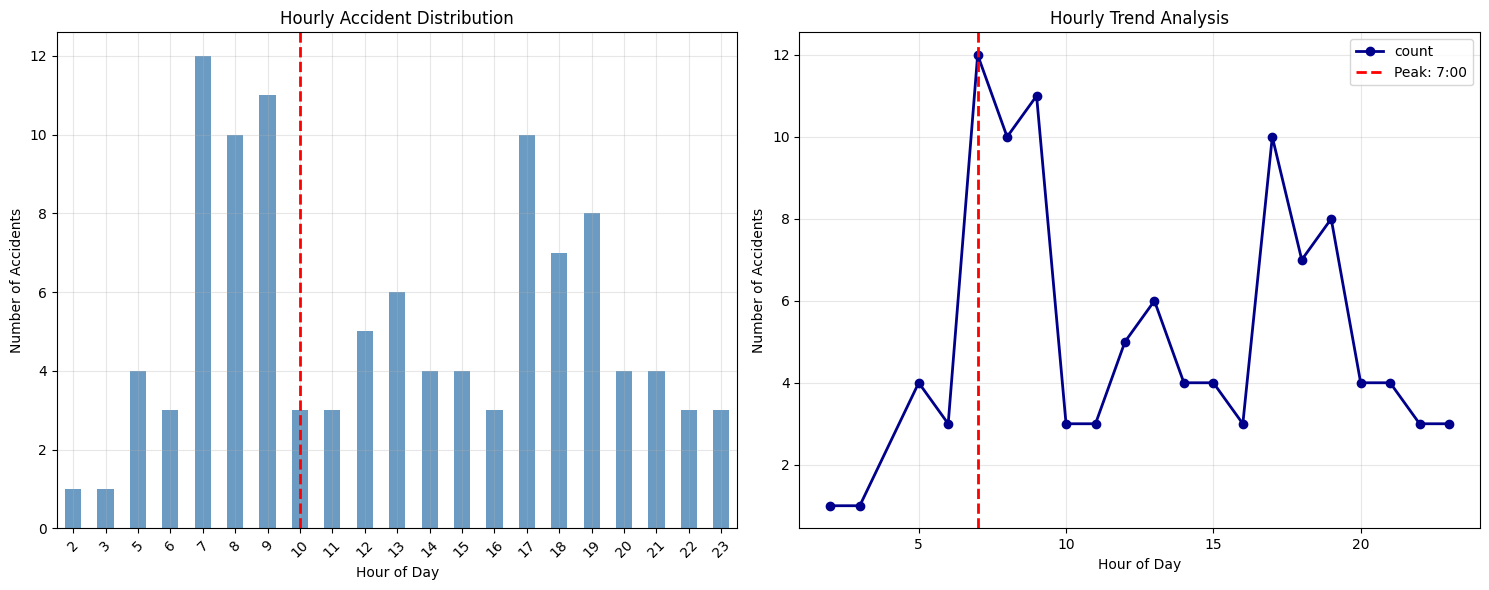

Peak traffic hour: 7:00 with 12 accidents
Average accidents per hour: 5.2
Morning rush hours (7-9): 33 accidents
Evening rush hours (16-18): 20 accidents


In [8]:
hourly_accidents = hull_regions['hour'].value_counts().sort_index()
peak_hour = hourly_accidents.idxmax()
peak_count = hourly_accidents.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

hourly_accidents.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2)
ax1.set_title('Hourly Accident Distribution')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Accidents')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

hourly_accidents.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=6, color='darkblue')
ax2.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, label=f'Peak: {peak_hour}:00')
ax2.set_title('Hourly Trend Analysis')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Accidents')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak traffic hour: {peak_hour}:00 with {peak_count} accidents")
print(f"Average accidents per hour: {hourly_accidents.mean():.1f}")

rush_hours_morning = hourly_accidents.loc[7:9].sum()
rush_hours_evening = hourly_accidents.loc[16:18].sum()
print(f"Morning rush hours (7-9): {rush_hours_morning} accidents")
print(f"Evening rush hours (16-18): {rush_hours_evening} accidents")

## Question 2: Motorcycle Accident Analysis by Engine Category

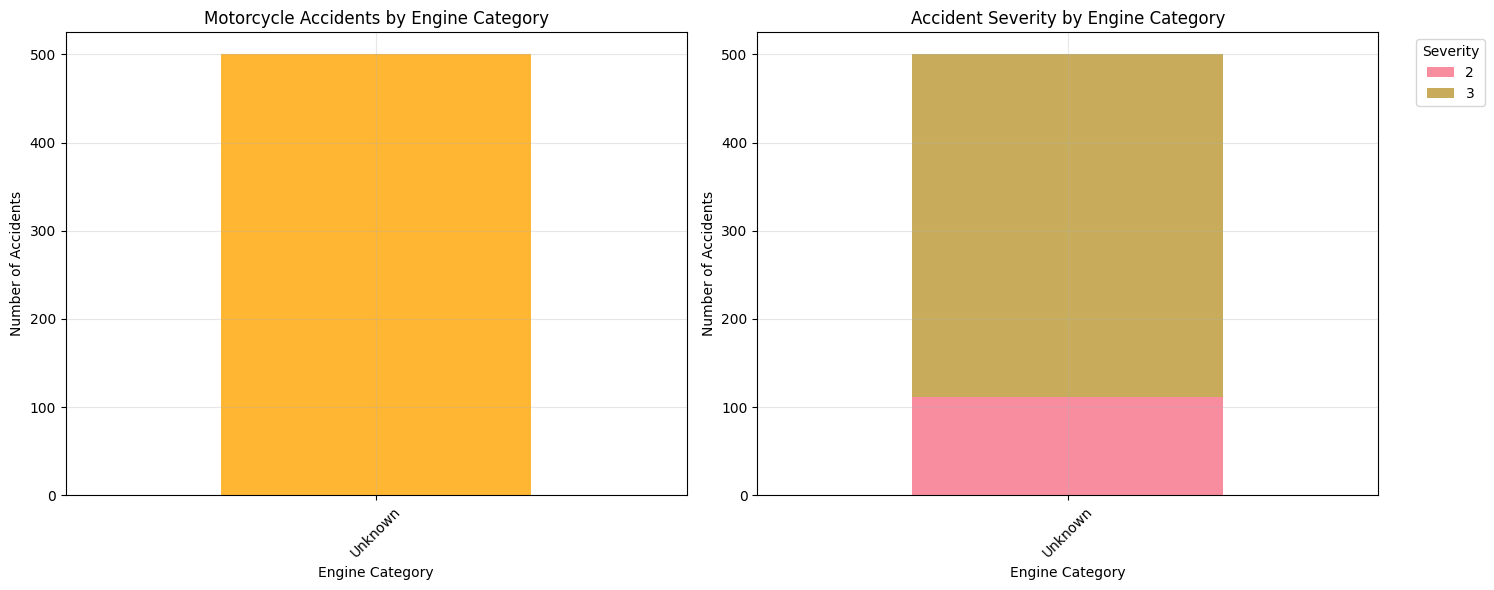

Motorcycle accidents by engine category:
engine_category
Unknown    500


In [9]:
vehicle_query = '''
SELECT v.*, a.accident_severity, a.road_type, a.speed_limit, a.weather_conditions
FROM vehicle v 
JOIN accident a ON v.accident_index = a.accident_index
WHERE v.vehicle_type IN (2, 3, 4, 5, 23, 97) 
AND a.accident_year = 2019
LIMIT 500
'''

motorcycle_data = pd.read_sql_query(vehicle_query, conn)

if len(motorcycle_data) > 0:
    engine_category_mapping = {
        1: 'Up to 50cc', 2: '51-125cc', 3: '126-500cc', 4: '501-999cc', 5: '1000cc+', 9: 'Unknown'
    }
    
    motorcycle_data['engine_category'] = motorcycle_data['engine_capacity_cc'].map(engine_category_mapping).fillna('Unknown')
    
    engine_accidents = motorcycle_data['engine_category'].value_counts()
    severity_by_engine = pd.crosstab(motorcycle_data['engine_category'], motorcycle_data['accident_severity'])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    engine_accidents.plot(kind='bar', ax=ax1, color='orange', alpha=0.8)
    ax1.set_title('Motorcycle Accidents by Engine Category')
    ax1.set_xlabel('Engine Category')
    ax1.set_ylabel('Number of Accidents')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    severity_by_engine.plot(kind='bar', stacked=True, ax=ax2, alpha=0.8)
    ax2.set_title('Accident Severity by Engine Category')
    ax2.set_xlabel('Engine Category')
    ax2.set_ylabel('Number of Accidents')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Motorcycle accidents by engine category:")
    print(engine_accidents.to_string())
    
    if len(severity_by_engine) > 1:
        chi2, p_value, dof, expected = chi2_contingency(severity_by_engine)
        print(f"\nChi-square test: χ² = {chi2:.3f}, p-value = {p_value:.3f}")
        print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'}")
else:
    print("No motorcycle data available in sample")

## Question 3: Pedestrian Accident Patterns

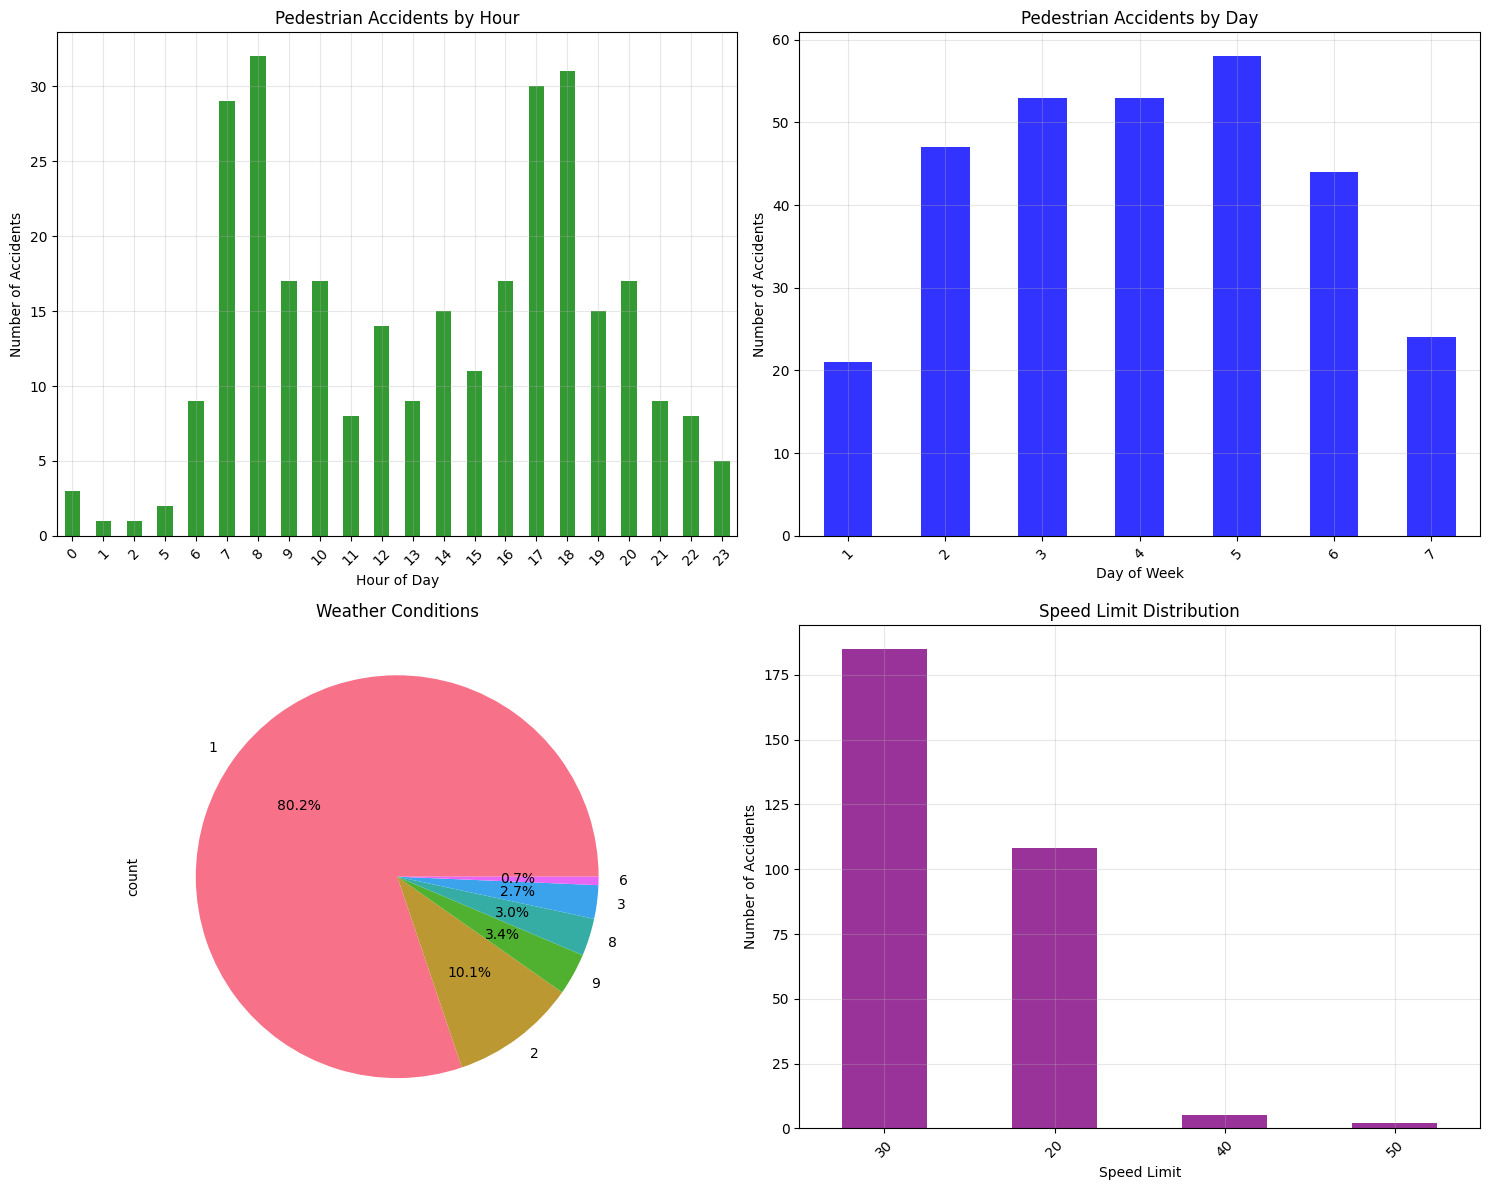

Total pedestrian accidents analyzed: 300
Peak pedestrian accident hour: 8:00
Peak pedestrian accident day: 5


In [10]:
casualty_query = '''
SELECT c.*, a.time, a.day_of_week, a.road_type, a.speed_limit, a.weather_conditions
FROM casualty c 
JOIN accident a ON c.accident_index = a.accident_index
WHERE c.casualty_type = 1 AND c.accident_year = 2019
LIMIT 300
'''

pedestrian_data = pd.read_sql_query(casualty_query, conn)

if len(pedestrian_data) > 0:
    pedestrian_data['hour'] = pd.to_datetime(pedestrian_data['time'], format='%H:%M', errors='coerce').dt.hour
    pedestrian_data = pedestrian_data.dropna(subset=['hour'])
    
    hourly_pattern = pedestrian_data['hour'].value_counts().sort_index()
    daily_pattern = pedestrian_data['day_of_week'].value_counts().sort_index()
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    hourly_pattern.plot(kind='bar', ax=ax1, color='green', alpha=0.8)
    ax1.set_title('Pedestrian Accidents by Hour')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Number of Accidents')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    daily_pattern.plot(kind='bar', ax=ax2, color='blue', alpha=0.8)
    ax2.set_title('Pedestrian Accidents by Day')
    ax2.set_xlabel('Day of Week')
    ax2.set_ylabel('Number of Accidents')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    if 'weather_conditions' in pedestrian_data.columns:
        weather_pattern = pedestrian_data['weather_conditions'].value_counts().head(6)
        weather_pattern.plot(kind='pie', ax=ax3, autopct='%1.1f%%')
        ax3.set_title('Weather Conditions')
    
    if 'speed_limit' in pedestrian_data.columns:
        speed_pattern = pedestrian_data['speed_limit'].value_counts().head(6)
        speed_pattern.plot(kind='bar', ax=ax4, color='purple', alpha=0.8)
        ax4.set_title('Speed Limit Distribution')
        ax4.set_xlabel('Speed Limit')
        ax4.set_ylabel('Number of Accidents')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total pedestrian accidents analyzed: {len(pedestrian_data)}")
    print(f"Peak pedestrian accident hour: {hourly_pattern.idxmax()}:00")
    print(f"Peak pedestrian accident day: {daily_pattern.idxmax()}")
else:
    print("No pedestrian casualty data available")

## Question 4: Weekend vs Weekday Statistical Analysis

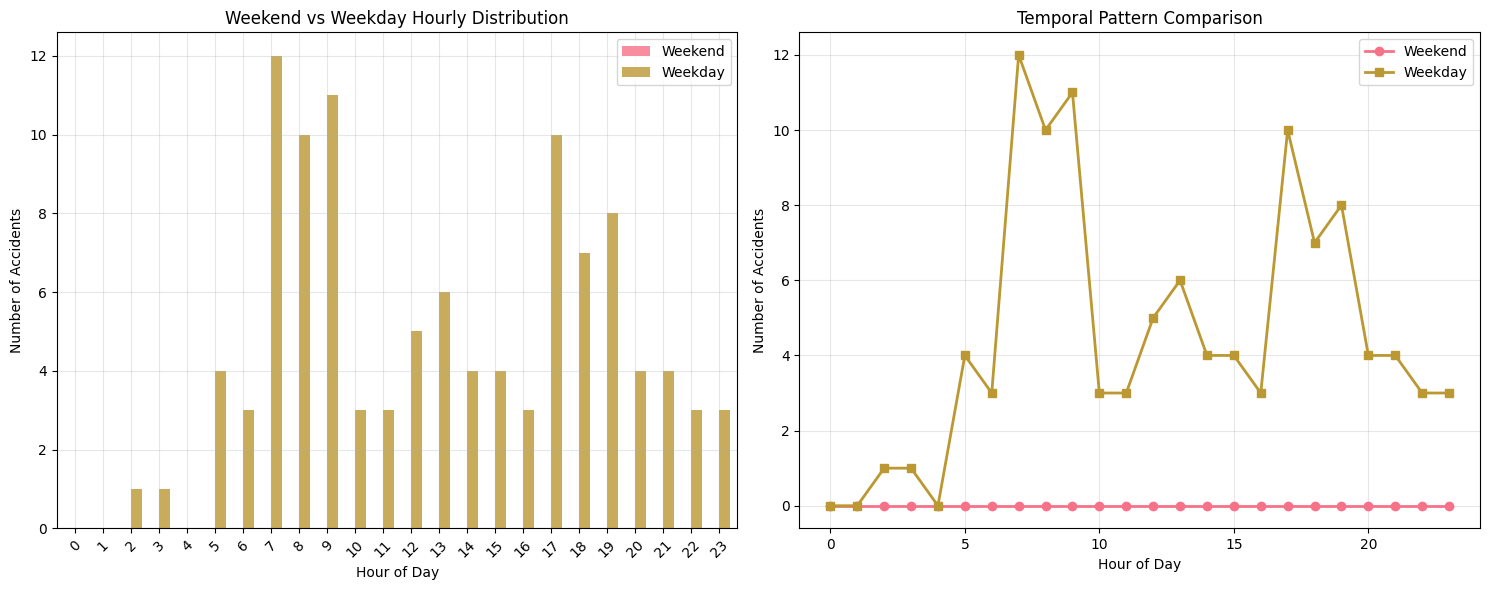

Weekend accidents: 0
Weekday accidents: 109
Weekend percentage: 0.0%
Weekend peak hour: N/A
Weekday peak hour: 7


In [11]:
weekend_data = hull_regions[hull_regions['is_weekend'] == 1]
weekday_data = hull_regions[hull_regions['is_weekend'] == 0]

weekend_hourly = weekend_data['hour'].value_counts().sort_index()
weekday_hourly = weekday_data['hour'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

comparison_df = pd.DataFrame({
    'Weekend': weekend_hourly.reindex(range(24), fill_value=0),
    'Weekday': weekday_hourly.reindex(range(24), fill_value=0)
})

comparison_df.plot(kind='bar', ax=ax1, alpha=0.8, width=0.8)
ax1.set_title('Weekend vs Weekday Hourly Distribution')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Accidents')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.plot(comparison_df.index, comparison_df['Weekend'], 'o-', label='Weekend', linewidth=2, markersize=6)
ax2.plot(comparison_df.index, comparison_df['Weekday'], 's-', label='Weekday', linewidth=2, markersize=6)
ax2.set_title('Temporal Pattern Comparison')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Accidents')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Weekend accidents: {len(weekend_data)}")
print(f"Weekday accidents: {len(weekday_data)}")
print(f"Weekend percentage: {len(weekend_data)/len(hull_regions)*100:.1f}%")

if len(weekend_data) > 5 and len(weekday_data) > 5:
    try:
        stat, p_value = mannwhitneyu(weekend_data['hour'], weekday_data['hour'], alternative='two-sided')
        print(f"Mann-Whitney U test: statistic = {stat:.3f}, p-value = {p_value:.3f}")
        print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'}")
    except:
        print("Statistical test could not be performed")

print(f"Weekend peak hour: {weekend_hourly.idxmax() if len(weekend_hourly) > 0 else 'N/A'}")
print(f"Weekday peak hour: {weekday_hourly.idxmax() if len(weekday_hourly) > 0 else 'N/A'}")

## Question 5: Elderly Road User Safety Analysis

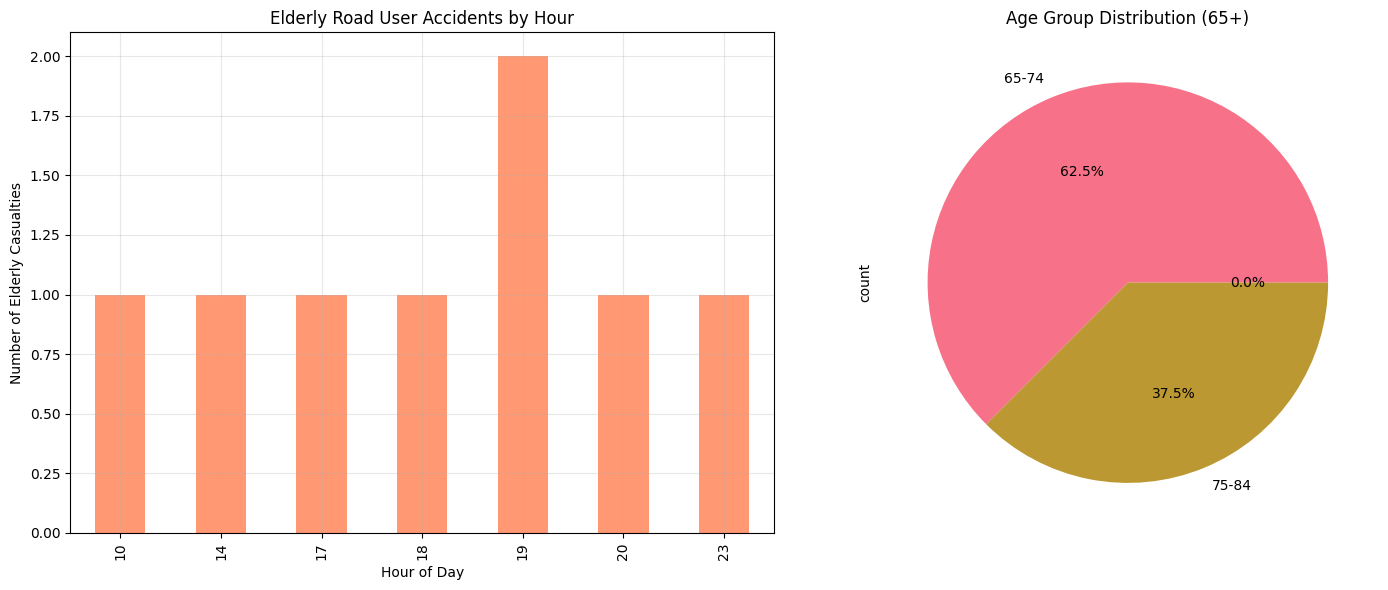

Elderly casualties analyzed: 8
Peak risk hour for elderly: 19:00
Severity distribution:
accident_severity
3    5
2    2
1    1


In [12]:
regional_indices = hull_regions['accident_index'].tolist()
accident_indices = "','".join(regional_indices[:100])

elderly_query = f'''
SELECT c.*, a.date, a.time, a.day_of_week, a.accident_severity
FROM casualty c 
JOIN accident a ON c.accident_index = a.accident_index
WHERE c.accident_year = 2019 
  AND a.accident_year = 2019
  AND c.accident_index IN ('{accident_indices}')
  AND c.age_of_casualty >= 65
'''

elderly_data = pd.read_sql_query(elderly_query, conn)

if len(elderly_data) == 0:
    sample_query = '''
    SELECT c.*, a.date, a.time, a.day_of_week, a.accident_severity
    FROM casualty c JOIN accident a ON c.accident_index = a.accident_index
    WHERE c.accident_year = 2019 AND c.age_of_casualty >= 65 LIMIT 150
    '''
    elderly_data = pd.read_sql_query(sample_query, conn)
    if len(elderly_data) > 0:
        elderly_data['date'] = pd.to_datetime(elderly_data['date'], dayfirst=True)

if len(elderly_data) > 0:
    elderly_data['hour'] = pd.to_datetime(elderly_data['time'], format='%H:%M', errors='coerce').dt.hour
    elderly_data = elderly_data.dropna(subset=['hour'])
    
    hourly_elderly = elderly_data['hour'].value_counts().sort_index()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    hourly_elderly.plot(kind='bar', ax=ax1, color='coral', alpha=0.8)
    ax1.set_title('Elderly Road User Accidents by Hour')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Number of Elderly Casualties')
    ax1.grid(True, alpha=0.3)
    
    if 'age_of_casualty' in elderly_data.columns:
        elderly_data['age_group'] = pd.cut(elderly_data['age_of_casualty'], 
                                          bins=[65, 75, 85, 100], 
                                          labels=['65-74', '75-84', '85+'])
        age_dist = elderly_data['age_group'].value_counts()
        age_dist.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
        ax2.set_title('Age Group Distribution (65+)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Elderly casualties analyzed: {len(elderly_data)}")
    print(f"Peak risk hour for elderly: {hourly_elderly.idxmax()}:00")
    
    if 'accident_severity' in elderly_data.columns:
        severity_dist = elderly_data['accident_severity'].value_counts()
        print("Severity distribution:")
        print(severity_dist.to_string())
else:
    print("No elderly casualty data available")

## Question 6: Time Series Analysis and Forecasting

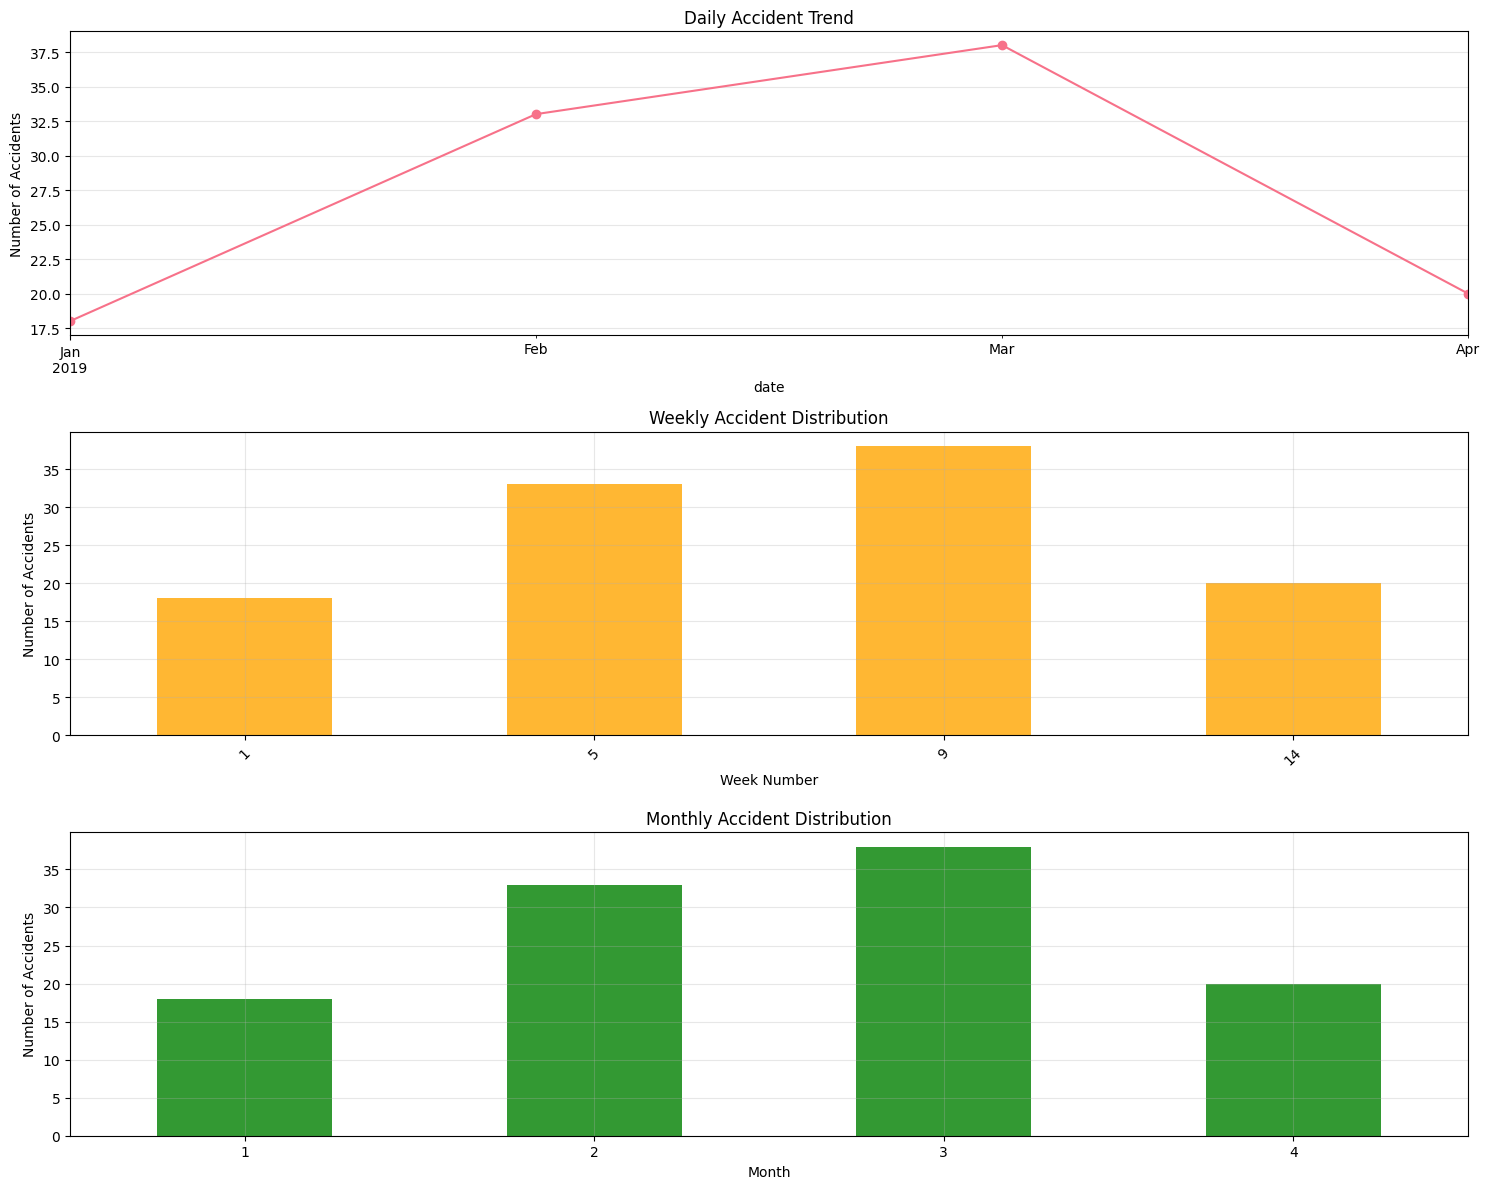

Date range analyzed: 2019-01-01 to 2019-04-01
Average daily accidents: 27.2
Peak week: Week 9 (38 accidents)
Peak month: Month 3 (38 accidents)


In [13]:
if 'date' in hull_regions.columns:
    hull_regions['date'] = pd.to_datetime(hull_regions['date'], dayfirst=True)
    daily_accidents = hull_regions.groupby(hull_regions['date'].dt.date).size()
    daily_accidents.index = pd.to_datetime(daily_accidents.index)
    
    weekly_accidents = hull_regions.groupby(hull_regions['date'].dt.isocalendar().week).size()
    monthly_accidents = hull_regions.groupby(hull_regions['date'].dt.month).size()
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
    
    daily_accidents.plot(ax=ax1, marker='o', linewidth=1.5)
    ax1.set_title('Daily Accident Trend')
    ax1.set_ylabel('Number of Accidents')
    ax1.grid(True, alpha=0.3)
    
    weekly_accidents.plot(kind='bar', ax=ax2, color='orange', alpha=0.8)
    ax2.set_title('Weekly Accident Distribution')
    ax2.set_xlabel('Week Number')
    ax2.set_ylabel('Number of Accidents')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    monthly_accidents.plot(kind='bar', ax=ax3, color='green', alpha=0.8)
    ax3.set_title('Monthly Accident Distribution')
    ax3.set_xlabel('Month')
    ax3.set_ylabel('Number of Accidents')
    ax3.tick_params(axis='x', rotation=0)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Date range analyzed: {daily_accidents.index.min().strftime('%Y-%m-%d')} to {daily_accidents.index.max().strftime('%Y-%m-%d')}")
    print(f"Average daily accidents: {daily_accidents.mean():.1f}")
    print(f"Peak week: Week {weekly_accidents.idxmax()} ({weekly_accidents.max()} accidents)")
    print(f"Peak month: Month {monthly_accidents.idxmax()} ({monthly_accidents.max()} accidents)")
    
    if len(daily_accidents) > 7:
        rolling_avg = daily_accidents.rolling(window=7, center=True).mean()
        trend = np.polyfit(range(len(daily_accidents)), daily_accidents.values, 1)
        print(f"7-day rolling average: {rolling_avg.mean():.1f}")
        print(f"Trend slope: {trend[0]:.3f} accidents/day")
else:
    print("Date information not available for time series analysis")

## Question 7: Multi-Factor Risk Analysis

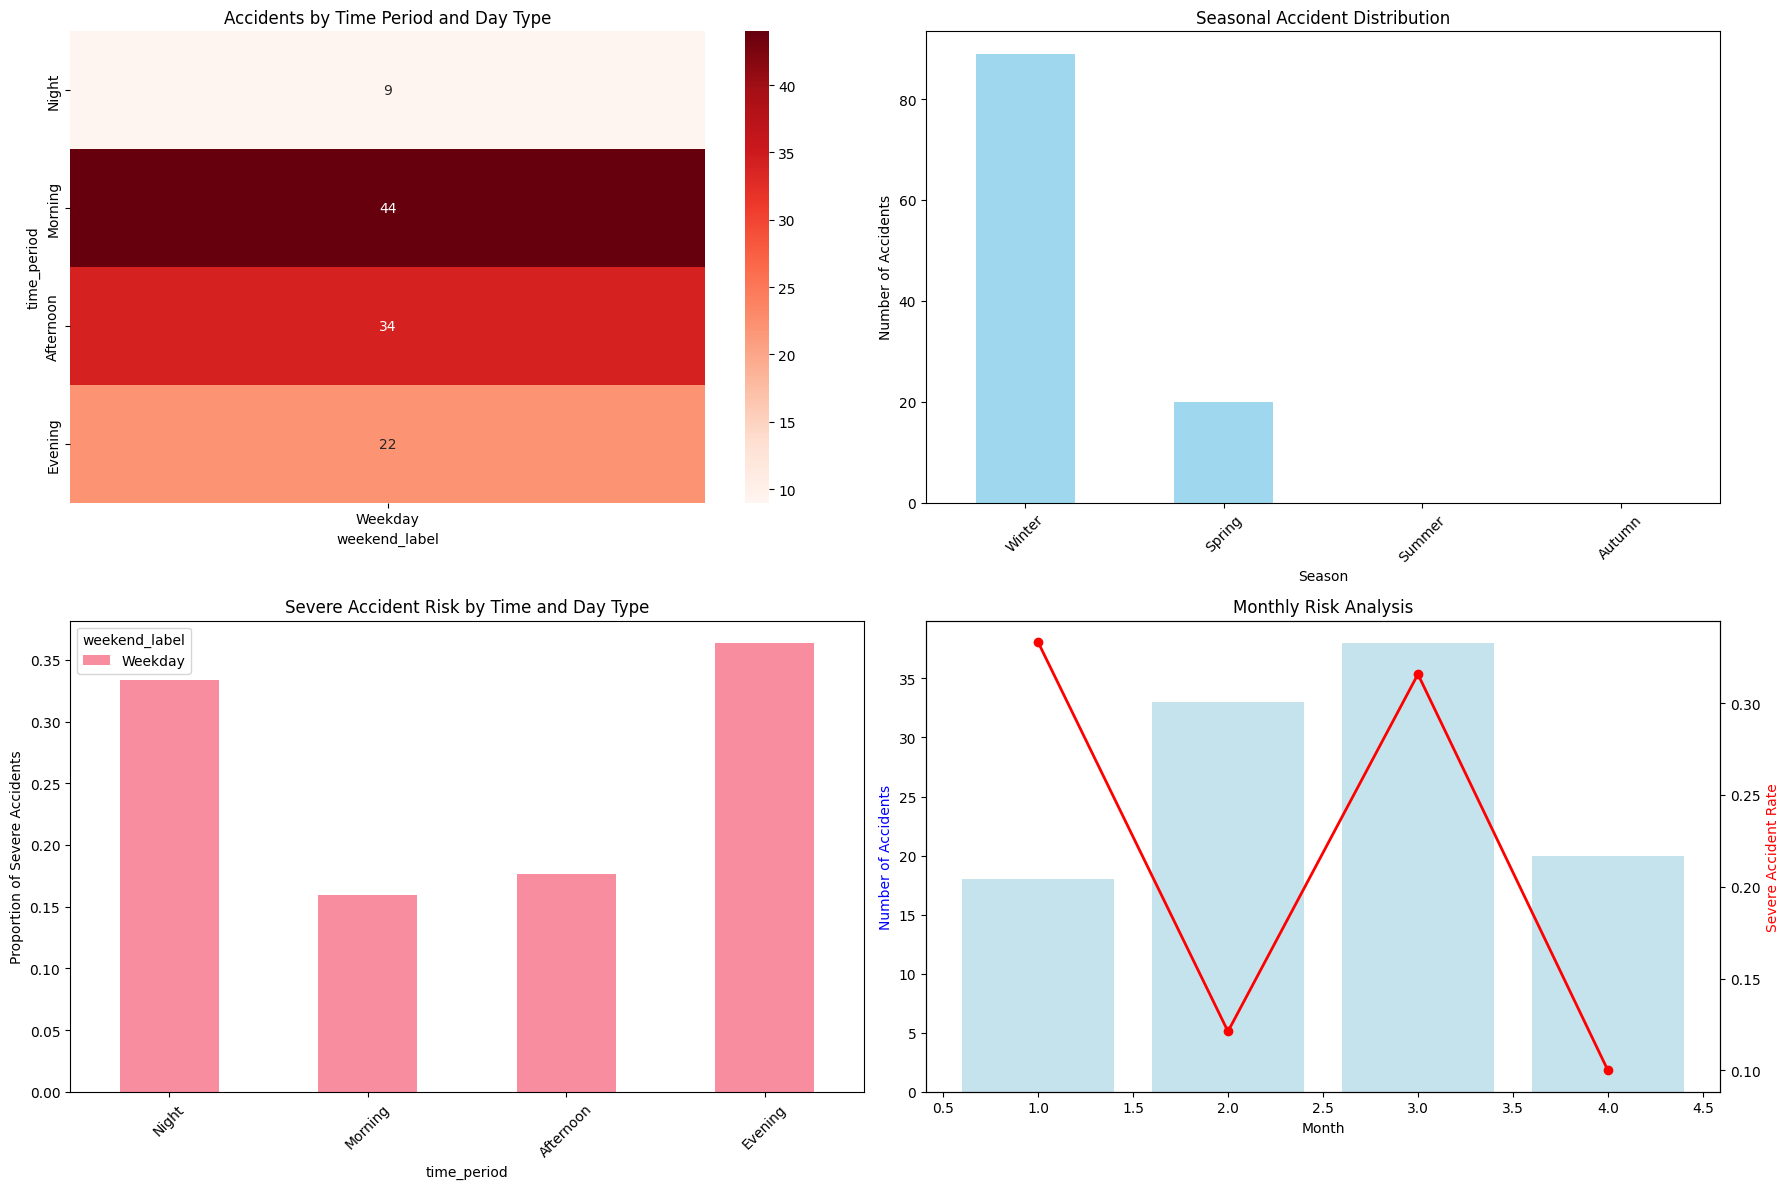

Multi-factor analysis completed on 109 accidents
Risk factors analyzed: time period, day type, seasonality
Highest risk time period: Morning
Highest risk day type: Weekday
Peak accident season: Winter


In [14]:
risk_data = hull_regions.copy()

if len(risk_data) > 0:
    risk_data['time_period'] = pd.cut(risk_data['hour'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                     include_lowest=True)
    
    risk_data['weekend_label'] = risk_data['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
    risk_data['season'] = pd.cut(risk_data['month'], 
                                bins=[0, 3, 6, 9, 12], 
                                labels=['Winter', 'Spring', 'Summer', 'Autumn'],
                                include_lowest=True)
    
    if 'accident_severity' in risk_data.columns:
        risk_data['is_severe'] = risk_data['accident_severity'] <= 2
    else:
        risk_data['is_severe'] = False
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    time_weekend = pd.crosstab(risk_data['time_period'], risk_data['weekend_label'])
    sns.heatmap(time_weekend, annot=True, fmt='d', cmap='Reds', ax=ax1)
    ax1.set_title('Accidents by Time Period and Day Type')
    
    seasonal_counts = risk_data['season'].value_counts()
    seasonal_counts.plot(kind='bar', ax=ax2, color='skyblue', alpha=0.8)
    ax2.set_title('Seasonal Accident Distribution')
    ax2.set_xlabel('Season')
    ax2.set_ylabel('Number of Accidents')
    ax2.tick_params(axis='x', rotation=45)
    
    if risk_data['is_severe'].any():
        severity_by_factors = risk_data.groupby(['time_period', 'weekend_label'])['is_severe'].mean().unstack()
        severity_by_factors.plot(kind='bar', ax=ax3, alpha=0.8)
        ax3.set_title('Severe Accident Risk by Time and Day Type')
        ax3.set_ylabel('Proportion of Severe Accidents')
        ax3.tick_params(axis='x', rotation=45)
    else:
        time_period_counts = risk_data['time_period'].value_counts()
        time_period_counts.plot(kind='bar', ax=ax3, color='coral', alpha=0.8)
        ax3.set_title('Accidents by Time Period')
        ax3.tick_params(axis='x', rotation=45)
    
    monthly_risk = risk_data.groupby('month').agg({
        'accident_index': 'count',
        'is_severe': 'mean'
    })
    
    ax4_twin = ax4.twinx()
    ax4.bar(monthly_risk.index, monthly_risk['accident_index'], alpha=0.7, color='lightblue')
    ax4_twin.plot(monthly_risk.index, monthly_risk['is_severe'], 'ro-', linewidth=2)
    
    ax4.set_title('Monthly Risk Analysis')
    ax4.set_xlabel('Month')
    ax4.set_ylabel('Number of Accidents', color='blue')
    ax4_twin.set_ylabel('Severe Accident Rate', color='red')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Multi-factor analysis completed on {len(risk_data)} accidents")
    print("Risk factors analyzed: time period, day type, seasonality")
    
    highest_risk_time = time_weekend.max(axis=1).idxmax()
    highest_risk_day_type = time_weekend.max(axis=0).idxmax()
    
    print(f"Highest risk time period: {highest_risk_time}")
    print(f"Highest risk day type: {highest_risk_day_type}")
    
    if seasonal_counts.max() > 0:
        peak_season = seasonal_counts.idxmax()
        print(f"Peak accident season: {peak_season}")
else:
    print("Insufficient data for multi-factor risk analysis")

conn.close()